In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
MODEL_PATH = "artifacts/xgboost_best.pkl"

with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)

print("Model loaded:", type(model))


Model loaded: <class 'xgboost.sklearn.XGBRegressor'>


In [3]:
DATA_PATH = "data/flights_cleaned.npz"

data = np.load(DATA_PATH)
X = data["X"]
y = data["y"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (271888, 34)
y shape: (271888,)


In [4]:
np.random.seed(42)

sample_size = 2000  # keep it small for quick visual check
idx = np.random.choice(len(X), size=sample_size, replace=False)

X_test_sample = X[idx]
y_test_sample = y[idx]

print("Sample shape:", X_test_sample.shape)


Sample shape: (2000, 34)


In [5]:
y_pred = model.predict(X_test_sample)


In [6]:
y_pred

array([ 481.4164 , 1124.1115 , 1174.9688 , ...,  301.60916,  987.071  ,
        545.94775], dtype=float32)

In [7]:
y_test_sample

array([ 481.42, 1124.11, 1174.97, ...,  301.61,  987.07,  545.95])

In [8]:
rmse = mean_squared_error(y_test_sample, y_pred, squared=False)
mae = mean_absolute_error(y_test_sample, y_pred)
r2 = r2_score(y_test_sample, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")


RMSE: 0.0039
MAE : 0.0019
R2  : 1.0000


In [9]:
results_df = pd.DataFrame({
    "actual_price": y_test_sample,
    "predicted_price": y_pred,
    "error": y_test_sample - y_pred
})

results_df.head(10)


,actual_price,predicted_price,error
0,481.42,481.416412,0.003588
1,1124.11,1124.111450,-0.001450
2,1174.97,1174.968750,0.001250
3,898.67,898.670532,-0.000532
4,959.91,959.912231,-0.002231
5,1367.60,1367.598999,0.001001
6,762.89,762.890198,-0.000198
7,1569.65,1569.651123,-0.001123
8,835.21,835.214600,-0.004600
9,674.52,674.519775,0.000225


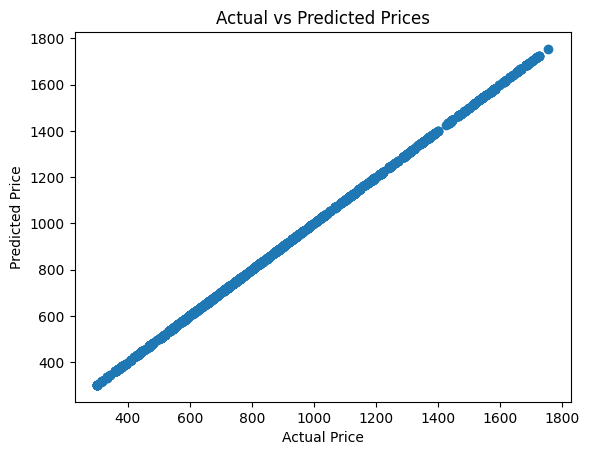

In [10]:
plt.figure()
plt.scatter(y_test_sample, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()


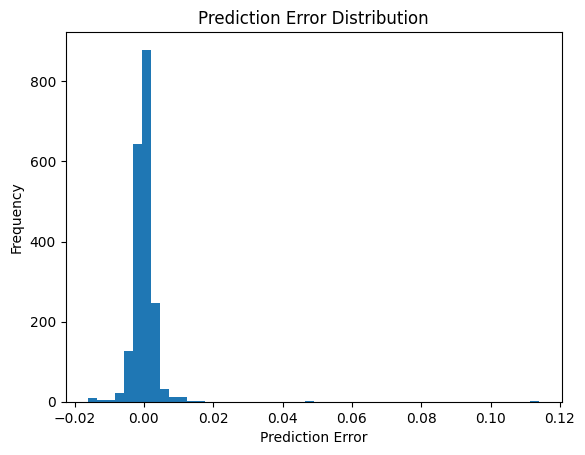

In [11]:
plt.figure()
plt.hist(y_test_sample - y_pred, bins=50)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution")
plt.show()


In [12]:
# Worst predictions (sanity check)

results_df["abs_error"] = np.abs(results_df["error"])
results_df.sort_values("abs_error", ascending=False).head(10)


,actual_price,predicted_price,error,abs_error
1512,654.88,654.765991,0.114009,0.114009
557,647.90,647.852478,0.047522,0.047522
486,541.59,541.606079,-0.016079,0.016079
282,541.59,541.606018,-0.016018,0.016018
1493,541.59,541.606018,-0.016018,0.016018
1387,541.59,541.606018,-0.016018,0.016018
1145,1128.51,1128.494019,0.015981,0.015981
1611,645.44,645.424683,0.015317,0.015317
228,661.32,661.334473,-0.014473,0.014473
98,1128.51,1128.495728,0.014272,0.014272
